In [ ]:
#1. # Load data

In [34]:
import pandas as pd
import numpy as np

#load CSV file 
df =pd.read_csv(r"C:\Users\Sonal.DESKTOP-0RFE5RA\OneDrive\Desktop\Data_Analyst\ECCOMERCE_PROJECT\ecommerce_orders.csv")
print("Data load successfully")


Data load successfully


In [35]:
# Convert customer_name to string
df['customer_phone'] = df['customer_phone'].astype('Int64').astype(str)
print("customer_pnone convert to string")

customer_pnone convert to string


In [36]:
# Display data size
print("Display data", df.shape)

Display data (60900, 18)


In [37]:
df.isnull().sum()

order_id               0
customer_name          0
customer_email      2416
customer_phone         0
customer_city       1299
product_name           0
category               0
seller_name            0
seller_city            0
unit_price             0
quantity               0
discount_pct           0
total_amount           0
order_date             0
payment_method         0
delivery_status        0
rating             17497
review_comment     11093
dtype: int64

In [ ]:
#2. Missing value 

In [38]:
df['customer_email'] = df['customer_email'].fillna("Unknown")
df['customer_city'] = df['customer_city'].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].median())
df['review_comment'] = df['review_comment'].fillna("Unknown")

In [39]:
df.isnull().sum()

order_id           0
customer_name      0
customer_email     0
customer_phone     0
customer_city      0
product_name       0
category           0
seller_name        0
seller_city        0
unit_price         0
quantity           0
discount_pct       0
total_amount       0
order_date         0
payment_method     0
delivery_status    0
rating             0
review_comment     0
dtype: int64

In [40]:
df.head()

,order_id,customer_name,customer_email,customer_phone,customer_city,product_name,category,seller_name,seller_city,unit_price,quantity,discount_pct,total_amount,order_date,payment_method,delivery_status,rating,review_comment
0,125677,Ayaan Sharma,ayaan.sharma@outlook.com,8857037617,Banglore,Zenith Biscuits Pack,Grocery,RetailHub Traders,Pune,63977.37,2,0,127954.74,07-05-2024,EMI,Cancelled,3.0,Unknown
1,127620,Vivaan Pillai,vivaan.pillai@yahoo.com,6354782376,AHMEDABAD,NovaLite Tablet,Electronics,UrbanCart Distributors,KOLKATA,51636.30,2,0,103272.60,12-02-2026,UPI,cancelled,4.0,Product damaged on arrival
2,139573,David Sharma,david.sharma@outlook.com,9464492897,Bengaluru,NovaLite Cooking Oil 1L,Grocery,UrbanCart Distributors,Bengaluru,49640.58,4,20,158849.86,09-05-2025,UPI,Delivered,3.0,Unknown
3,141579,Vivaan Williams,vivaan.williams@gmail.com,7540243542,Chennai,NovaLite Formal Shirt,Fashion,CityMart Suppliers,pune,24390.58,1,0,24390.58,19-07-2024,credit card,cancelled,1.0,Excellent value for money
4,100501,Sarah Desai,sarah.desai@outlook.com,6321480212,bangalore,Classico Air Fryer,Home & Kitchen,TrendyStore Pvt Ltd,AHMEDABAD,60324.10,4,0,241296.40,21-12-2024,cod,Pending,2.0,Excellent value for money


In [ ]:
#3. Remove Extra Spaces

In [41]:
## Remove leading/trailing spaces from all string columns
df = df.apply(lambda x: x.str.strip() if x.dtype=="object" else x)

In [ ]:
#4. Standardize Case

In [42]:
text_cols = [
    "customer_city",
    "seller_city",
    "delivery_status"
]

for col in text_cols:
    df[col] = df[col].str.title()

In [43]:
df['payment_method'] = df['payment_method'].str.upper()

In [44]:
df.head()

,order_id,customer_name,customer_email,customer_phone,customer_city,product_name,category,seller_name,seller_city,unit_price,quantity,discount_pct,total_amount,order_date,payment_method,delivery_status,rating,review_comment
0,125677,Ayaan Sharma,ayaan.sharma@outlook.com,8857037617,Banglore,Zenith Biscuits Pack,Grocery,RetailHub Traders,Pune,63977.37,2,0,127954.74,07-05-2024,EMI,Cancelled,3.0,Unknown
1,127620,Vivaan Pillai,vivaan.pillai@yahoo.com,6354782376,Ahmedabad,NovaLite Tablet,Electronics,UrbanCart Distributors,Kolkata,51636.30,2,0,103272.60,12-02-2026,UPI,Cancelled,4.0,Product damaged on arrival
2,139573,David Sharma,david.sharma@outlook.com,9464492897,Bengaluru,NovaLite Cooking Oil 1L,Grocery,UrbanCart Distributors,Bengaluru,49640.58,4,20,158849.86,09-05-2025,UPI,Delivered,3.0,Unknown
3,141579,Vivaan Williams,vivaan.williams@gmail.com,7540243542,Chennai,NovaLite Formal Shirt,Fashion,CityMart Suppliers,Pune,24390.58,1,0,24390.58,19-07-2024,CREDIT CARD,Cancelled,1.0,Excellent value for money
4,100501,Sarah Desai,sarah.desai@outlook.com,6321480212,Bangalore,Classico Air Fryer,Home & Kitchen,TrendyStore Pvt Ltd,Ahmedabad,60324.10,4,0,241296.40,21-12-2024,COD,Pending,2.0,Excellent value for money


In [ ]:
#5. Fix City Names

In [45]:
city_fix = {
    "Banglore":"Bangalore",
    "bangalore":"Bangalore",
    "Bengaluru":"Bangalore",

    "Bombay":"Mumbai",
    "Mumbai ":"Mumbai",
    "mumbai":"Mumbai",

    "Madras":"Chennai",
    "chennai":"Chennai",
    "CHENNAI":"Chennai",

    "Poona":"Pune",
    "pune":"Pune",
    "PUNE":"Pune",

    "Calcutta":"Kolkata",
    "kolkata":"Kolkata",
    "KOLKATA":"Kolkata",

    "Ahmdabad":"Ahmedabad",
    "AHMEDABAD":"Ahmedabad",
    "ahmedabad":"Ahmedabad",

    "Hyderbad":"Hyderabad",
    "HYDERABAD":"Hyderabad",
    "hyderabad":"Hyderabad"
}
df['customer_city'] = df['customer_city'].replace(city_fix)
df['seller_city'] = df['seller_city'].replace(city_fix)
print("\nStep 5 -> City spellings fixed. Ab kitne unique cities hain:", df['customer_city'].nunique())
 


Step 5 -> City spellings fixed. Ab kitne unique cities hain: 10


In [46]:
df.head(20)

,order_id,customer_name,customer_email,customer_phone,customer_city,product_name,category,seller_name,seller_city,unit_price,quantity,discount_pct,total_amount,order_date,payment_method,delivery_status,rating,review_comment
0,125677,Ayaan Sharma,ayaan.sharma@outlook.com,8857037617,Bangalore,Zenith Biscuits Pack,Grocery,RetailHub Traders,Pune,63977.37,2,0,127954.74,07-05-2024,EMI,Cancelled,3.0,Unknown
1,127620,Vivaan Pillai,vivaan.pillai@yahoo.com,6354782376,Ahmedabad,NovaLite Tablet,Electronics,UrbanCart Distributors,Kolkata,51636.30,2,0,103272.60,12-02-2026,UPI,Cancelled,4.0,Product damaged on arrival
2,139573,David Sharma,david.sharma@outlook.com,9464492897,Bangalore,NovaLite Cooking Oil 1L,Grocery,UrbanCart Distributors,Bangalore,49640.58,4,20,158849.86,09-05-2025,UPI,Delivered,3.0,Unknown
3,141579,Vivaan Williams,vivaan.williams@gmail.com,7540243542,Chennai,NovaLite Formal Shirt,Fashion,CityMart Suppliers,Pune,24390.58,1,0,24390.58,19-07-2024,CREDIT CARD,Cancelled,1.0,Excellent value for money
4,100501,Sarah Desai,sarah.desai@outlook.com,6321480212,Bangalore,Classico Air Fryer,Home & Kitchen,TrendyStore Pvt Ltd,Ahmedabad,60324.10,4,0,241296.40,21-12-2024,COD,Pending,2.0,Excellent value for money
5,112474,Saanvi Davis,saanvi.davis@yahoo.com,8576095915,Mumbai,Vortek Women Handbag,Fashion,NextGen Traders,Hyderabad,51903.49,5,0,259517.45,27-07-2024,CREDIT CARD,Shipped,4.0,Unknown
6,159660,David Rao,david.rao@yahoo.com,9404476600,Pune,PrimeTech Cooking Oil 1L,Grocery,UrbanCart Distributors,Chennai,29676.28,2,5,56384.93,31-10-2022,CREDIT CARD,Cancelled,3.0,Unknown
7,146518,Vivaan Kapoor,vivaan.kapoor@gmail.com,6187623171,Pune,Zenith History Book,Books,MegaMart Wholesale,Chennai,38249.52,4,0,152998.08,13-01-2026,COD,Delivered,4.0,Unknown
8,112670,David Reddy,david.reddy@hotmail.com,8119132188,Hyderabad,PrimeTech Formal Shirt,Fashion,SwiftRetail Co,Bangalore,8614.76,2,0,17229.52,15-10-2025,EMI,Delivered,3.0,Excellent value for money
9,106560,Karan Iyer,karan991@hotmail.com,8776460161,Kolkata,Zenith Cooking Oil 1L,Grocery,MegaMart Wholesale,Hyderabad,24164.16,3,0,72492.48,04-03-2025,CREDIT CARD,Cancelled,4.0,Excellent value for money


In [ ]:
#6. Standardize Payment Method

In [63]:
payment_fix = {"Cod":"CASH ON DELIVERY","COD":"CASH ON DELIVERY","cod":"CASH ON DELIVERY", "Cash On Delivery":"CASH ON DELIVERY"}
df['payment_method'] = df['payment_method'].replace(payment_fix)


In [66]:
df.head(10)

,order_id,customer_name,customer_email,customer_phone,customer_city,product_name,category,seller_name,seller_city,unit_price,quantity,discount_pct,total_amount,order_date,payment_method,delivery_status,rating,review_comment
0,125677,Ayaan Sharma,ayaan.sharma@outlook.com,8857037617,Bangalore,Zenith Biscuits Pack,Grocery,RetailHub Traders,Pune,63977.37,2,0,127954.74,2024-05-07,EMI,Cancelled,3.0,Unknown
1,127620,Vivaan Pillai,vivaan.pillai@yahoo.com,6354782376,Ahmedabad,NovaLite Tablet,Electronics,UrbanCart Distributors,Kolkata,51636.30,2,0,103272.60,2026-02-12,UPI,Cancelled,4.0,Product damaged on arrival
2,139573,David Sharma,david.sharma@outlook.com,9464492897,Bangalore,NovaLite Cooking Oil 1L,Grocery,UrbanCart Distributors,Bangalore,49640.58,4,20,158849.86,2025-05-09,UPI,Delivered,3.0,Unknown
3,141579,Vivaan Williams,vivaan.williams@gmail.com,7540243542,Chennai,NovaLite Formal Shirt,Fashion,CityMart Suppliers,Pune,24390.58,1,0,24390.58,2024-07-19,CREDIT CARD,Cancelled,1.0,Excellent value for money
4,100501,Sarah Desai,sarah.desai@outlook.com,6321480212,Bangalore,Classico Air Fryer,Home & Kitchen,TrendyStore Pvt Ltd,Ahmedabad,60324.10,4,0,241296.40,2024-12-21,CASH ON DELIVERY,Pending,2.0,Excellent value for money
5,112474,Saanvi Davis,saanvi.davis@yahoo.com,8576095915,Mumbai,Vortek Women Handbag,Fashion,NextGen Traders,Hyderabad,51903.49,5,0,259517.45,2024-07-27,CREDIT CARD,Shipped,4.0,Unknown
6,159660,David Rao,david.rao@yahoo.com,9404476600,Pune,PrimeTech Cooking Oil 1L,Grocery,UrbanCart Distributors,Chennai,29676.28,2,5,56384.93,2022-10-31,CREDIT CARD,Cancelled,3.0,Unknown
7,146518,Vivaan Kapoor,vivaan.kapoor@gmail.com,6187623171,Pune,Zenith History Book,Books,MegaMart Wholesale,Chennai,38249.52,4,0,152998.08,2026-01-13,CASH ON DELIVERY,Delivered,4.0,Unknown
8,112670,David Reddy,david.reddy@hotmail.com,8119132188,Hyderabad,PrimeTech Formal Shirt,Fashion,SwiftRetail Co,Bangalore,8614.76,2,0,17229.52,2025-10-15,EMI,Delivered,3.0,Excellent value for money
9,106560,Karan Iyer,karan991@hotmail.com,8776460161,Kolkata,Zenith Cooking Oil 1L,Grocery,MegaMart Wholesale,Hyderabad,24164.16,3,0,72492.48,2025-03-04,CREDIT CARD,Cancelled,4.0,Excellent value for money


In [ ]:
#7. Date Format Fix

In [48]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [49]:
df.head()

,order_id,customer_name,customer_email,customer_phone,customer_city,product_name,category,seller_name,seller_city,unit_price,quantity,discount_pct,total_amount,order_date,payment_method,delivery_status,rating,review_comment
0,125677,Ayaan Sharma,ayaan.sharma@outlook.com,8857037617,Bangalore,Zenith Biscuits Pack,Grocery,RetailHub Traders,Pune,63977.37,2,0,127954.74,2024-05-07,EMI,Cancelled,3.0,Unknown
1,127620,Vivaan Pillai,vivaan.pillai@yahoo.com,6354782376,Ahmedabad,NovaLite Tablet,Electronics,UrbanCart Distributors,Kolkata,51636.30,2,0,103272.60,2026-02-12,UPI,Cancelled,4.0,Product damaged on arrival
2,139573,David Sharma,david.sharma@outlook.com,9464492897,Bangalore,NovaLite Cooking Oil 1L,Grocery,UrbanCart Distributors,Bangalore,49640.58,4,20,158849.86,2025-05-09,UPI,Delivered,3.0,Unknown
3,141579,Vivaan Williams,vivaan.williams@gmail.com,7540243542,Chennai,NovaLite Formal Shirt,Fashion,CityMart Suppliers,Pune,24390.58,1,0,24390.58,2024-07-19,CREDIT CARD,Cancelled,1.0,Excellent value for money
4,100501,Sarah Desai,sarah.desai@outlook.com,6321480212,Bangalore,Classico Air Fryer,Home & Kitchen,TrendyStore Pvt Ltd,Ahmedabad,60324.10,4,0,241296.40,2024-12-21,COD,Pending,2.0,Excellent value for money


In [ ]:
#8. Multi-value Split

In [67]:
df['product_name'] = df['product_name'].str.split(',').apply(lambda x: [i.strip() for i in x])
df['category'] = df['category'].str.split(',').apply(lambda x: [i.strip() for i in x])

df = df.explode(['product_name', 'category'], ignore_index=True)

In [69]:
df.head(50)


,order_id,customer_name,customer_email,customer_phone,customer_city,product_name,category,seller_name,seller_city,unit_price,quantity,discount_pct,total_amount,order_date,payment_method,delivery_status,rating,review_comment
0,125677,Ayaan Sharma,ayaan.sharma@outlook.com,8857037617,Bangalore,Zenith Biscuits Pack,Grocery,RetailHub Traders,Pune,63977.37,2,0,127954.74,2024-05-07,EMI,Cancelled,3.0,Unknown
1,127620,Vivaan Pillai,vivaan.pillai@yahoo.com,6354782376,Ahmedabad,NovaLite Tablet,Electronics,UrbanCart Distributors,Kolkata,51636.30,2,0,103272.60,2026-02-12,UPI,Cancelled,4.0,Product damaged on arrival
2,139573,David Sharma,david.sharma@outlook.com,9464492897,Bangalore,NovaLite Cooking Oil 1L,Grocery,UrbanCart Distributors,Bangalore,49640.58,4,20,158849.86,2025-05-09,UPI,Delivered,3.0,Unknown
3,141579,Vivaan Williams,vivaan.williams@gmail.com,7540243542,Chennai,NovaLite Formal Shirt,Fashion,CityMart Suppliers,Pune,24390.58,1,0,24390.58,2024-07-19,CREDIT CARD,Cancelled,1.0,Excellent value for money
4,100501,Sarah Desai,sarah.desai@outlook.com,6321480212,Bangalore,Classico Air Fryer,Home & Kitchen,TrendyStore Pvt Ltd,Ahmedabad,60324.10,4,0,241296.40,2024-12-21,CASH ON DELIVERY,Pending,2.0,Excellent value for money
5,112474,Saanvi Davis,saanvi.davis@yahoo.com,8576095915,Mumbai,Vortek Women Handbag,Fashion,NextGen Traders,Hyderabad,51903.49,5,0,259517.45,2024-07-27,CREDIT CARD,Shipped,4.0,Unknown
6,159660,David Rao,david.rao@yahoo.com,9404476600,Pune,PrimeTech Cooking Oil 1L,Grocery,UrbanCart Distributors,Chennai,29676.28,2,5,56384.93,2022-10-31,CREDIT CARD,Cancelled,3.0,Unknown
7,146518,Vivaan Kapoor,vivaan.kapoor@gmail.com,6187623171,Pune,Zenith History Book,Books,MegaMart Wholesale,Chennai,38249.52,4,0,152998.08,2026-01-13,CASH ON DELIVERY,Delivered,4.0,Unknown
8,112670,David Reddy,david.reddy@hotmail.com,8119132188,Hyderabad,PrimeTech Formal Shirt,Fashion,SwiftRetail Co,Bangalore,8614.76,2,0,17229.52,2025-10-15,EMI,Delivered,3.0,Excellent value for money
9,106560,Karan Iyer,karan991@hotmail.com,8776460161,Kolkata,Zenith Cooking Oil 1L,Grocery,MegaMart Wholesale,Hyderabad,24164.16,3,0,72492.48,2025-03-04,CREDIT CARD,Cancelled,4.0,Excellent value for money


In [ ]:
#9. Numeric Cleaning

In [70]:
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['total_amount'] = pd.to_numeric(df['total_amount'], errors='coerce')
df['discount_pct'] = pd.to_numeric(df['discount_pct'], errors='coerce')

In [ ]:
#10. Data Validation
Final Amount = Unit Price × Quantity × (1 - Discount/100)

In [71]:
df['calculated_total'] = df['unit_price'] * df['quantity'] *(1 - df['discount_pct']/100)
df[['total_amount', 'calculated_total']]

,total_amount,calculated_total
0,127954.74,127954.740
1,103272.60,103272.600
2,158849.86,158849.856
3,24390.58,24390.580
4,241296.40,241296.400
...,...,...
64600,13490.14,13490.144
64601,72901.87,72901.872
64602,48626.36,48626.360
64603,201027.30,201027.300


In [72]:
df.to_csv("orders_clean.csv", index=False)

In [1]:
import pandas as pd 
df = pd.read_csv("orders_clean.csv")
print("Data successful loaded")
df['customer_phone'] = df['customer_phone'].astype('Int64').astype(str)
print("customer_phone convert to string")
df.head()


Data successful loaded
customer_phone convert to string


,order_id,customer_name,customer_email,customer_phone,customer_city,product_name,category,seller_name,seller_city,unit_price,quantity,discount_pct,total_amount,order_date,payment_method,delivery_status,rating,review_comment,calculated_total
0,125677,Ayaan Sharma,ayaan.sharma@outlook.com,8857037617,Bangalore,Zenith Biscuits Pack,Grocery,RetailHub Traders,Pune,63977.37,2,0,127954.74,2024-05-07,EMI,Cancelled,3.0,Unknown,127954.740
1,127620,Vivaan Pillai,vivaan.pillai@yahoo.com,6354782376,Ahmedabad,NovaLite Tablet,Electronics,UrbanCart Distributors,Kolkata,51636.30,2,0,103272.60,2026-02-12,UPI,Cancelled,4.0,Product damaged on arrival,103272.600
2,139573,David Sharma,david.sharma@outlook.com,9464492897,Bangalore,NovaLite Cooking Oil 1L,Grocery,UrbanCart Distributors,Bangalore,49640.58,4,20,158849.86,2025-05-09,UPI,Delivered,3.0,Unknown,158849.856
3,141579,Vivaan Williams,vivaan.williams@gmail.com,7540243542,Chennai,NovaLite Formal Shirt,Fashion,CityMart Suppliers,Pune,24390.58,1,0,24390.58,2024-07-19,CREDIT CARD,Cancelled,1.0,Excellent value for money,24390.580
4,100501,Sarah Desai,sarah.desai@outlook.com,6321480212,Bangalore,Classico Air Fryer,Home & Kitchen,TrendyStore Pvt Ltd,Ahmedabad,60324.10,4,0,241296.40,2024-12-21,CASH ON DELIVERY,Pending,2.0,Excellent value for money,241296.400


In [ ]:
#STEP 1: Insight

In [ ]:
# STEP 2: Total Business Overview

In [2]:
Total_sale = df['total_amount'].sum()
Total_orders = df['order_id'].nunique()
Avg_order_value = df['total_amount'].mean()
print(Total_sale, Total_orders, Avg_order_value)

4218653678.91 60000 65299.18239934989


In [ ]:
#STEP 3: Category Analysis

In [5]:
Category_Sales = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)
print(Category_Sales)

category
Home & Kitchen    8.064673e+08
Fashion           8.008733e+08
Beauty            7.492260e+08
Electronics       6.950290e+08
Books             5.871710e+08
Grocery           5.798872e+08
Name: total_amount, dtype: float64


In [ ]:
# STEP 4: Monthly Trend Analysis

In [14]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month_name()
monthly_sales = df.groupby('month')['total_amount'].sum().reset_index()
print(monthly_sales)

        month  total_amount
0       April  3.872872e+08
1      August  3.337992e+08
2    December  3.266975e+08
3    February  3.602118e+08
4     January  3.974762e+08
5        July  3.163209e+08
6        June  3.909810e+08
7       March  3.919011e+08
8         May  3.916435e+08
9    November  3.129530e+08
10    October  3.048468e+08
11  September  3.045354e+08


In [ ]:
#chronological order

In [17]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month_name()
monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))['total_amount']
      .sum()
      .reset_index()
)

monthly_sales['order_date'] = monthly_sales['order_date'].astype(str)

print(monthly_sales)

   order_date  total_amount
0     2022-01   84603390.73
1     2022-02   72965554.30
2     2022-03   77175640.08
3     2022-04   77548519.91
4     2022-05   81201892.76
5     2022-06   77067434.71
6     2022-07   81178660.38
7     2022-08   82219343.00
8     2022-09   74824169.44
9     2022-10   72969994.80
10    2022-11   81686869.89
11    2022-12   82755670.11
12    2023-01   75859359.68
13    2023-02   69405349.92
14    2023-03   77545870.53
15    2023-04   82866646.96
16    2023-05   81117169.17
17    2023-06   86546014.70
18    2023-07   78537563.97
19    2023-08   83783884.38
20    2023-09   70857845.02
21    2023-10   76208340.58
22    2023-11   75399462.04
23    2023-12   78625665.90
24    2024-01   83871333.58
25    2024-02   76533254.56
26    2024-03   77189834.46
27    2024-04   78365075.37
28    2024-05   73560255.42
29    2024-06   80471430.62
30    2024-07   79204066.22
31    2024-08   82709927.42
32    2024-09   76957960.33
33    2024-10   78088735.79
34    2024-11   7519

In [18]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_sales = (
    df.groupby(df['order_date'].dt.strftime('%b %Y'))['total_amount']
      .sum()
      .reset_index()
)

print(monthly_sales)

   order_date  total_amount
0    Apr 2022   77548519.91
1    Apr 2023   82866646.96
2    Apr 2024   78365075.37
3    Apr 2025   69537706.69
4    Apr 2026   78969276.43
5    Aug 2022   82219343.00
6    Aug 2023   83783884.38
7    Aug 2024   82709927.42
8    Aug 2025   85086075.33
9    Dec 2022   82755670.11
10   Dec 2023   78625665.90
11   Dec 2024   80625678.71
12   Dec 2025   84690526.59
13   Feb 2022   72965554.30
14   Feb 2023   69405349.92
15   Feb 2024   76533254.56
16   Feb 2025   70714958.89
17   Feb 2026   70592684.26
18   Jan 2022   84603390.73
19   Jan 2023   75859359.68
20   Jan 2024   83871333.58
21   Jan 2025   77870527.97
22   Jan 2026   75271543.03
23   Jul 2022   81178660.38
24   Jul 2023   78537563.97
25   Jul 2024   79204066.22
26   Jul 2025   77400575.70
27   Jun 2022   77067434.71
28   Jun 2023   86546014.70
29   Jun 2024   80471430.62
30   Jun 2025   78061895.03
31   Jun 2026   68834268.38
32   Mar 2022   77175640.08
33   Mar 2023   77545870.53
34   Mar 2024   7718

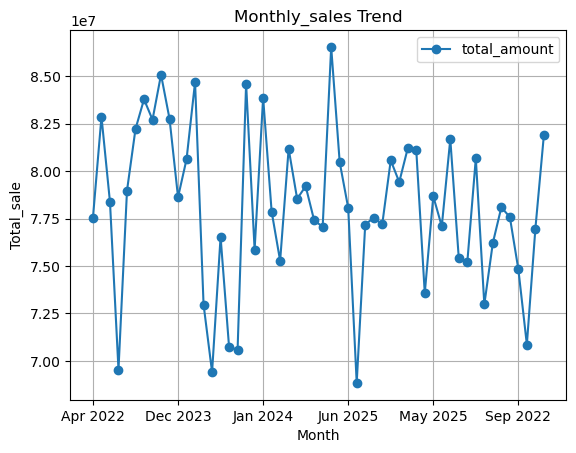

In [21]:
import matplotlib.pyplot as plt
monthly_sales.plot(x='order_date', y='total_amount', kind='line', marker='o')
plt.title("Monthly_sales Trend")
plt.xlabel("Month")
plt.ylabel("Total_sale")
plt.grid(True)
plt.show()

In [ ]:
# STEP 5: Top Products

In [27]:
top_products = df.groupby('product_name')['total_amount']\
                .sum().sort_values(ascending=False).head(10)
print(top_products)

product_name
Fusion Nail Polish Set           48314581.87
PrimeTech Children Story Book    47965887.49
Vortek Women Handbag             42953788.60
NovaLite Moisturizer Cream       36154881.03
PrimeTech Storage Boxes          35672688.53
Fusion Bluetooth Earbuds         35614524.51
PrimeTech Cooking Oil 1L         34665563.88
Zenith Nail Polish Set           34200188.66
NovaLite Bed Sheet Set           33873822.28
Aeon Power Bank                  33278130.24
Name: total_amount, dtype: float64


In [ ]:
# STEP 6: Customer Analysis

In [32]:
top_customers = df.groupby('customer_name')['total_amount']\
                  .sum().sort_values(ascending=False).head(5)
print(top_customers)



customer_name
Navya Mehta       8481235.20
Sarah Miller      7917431.20
Ananya Bose       7877106.18
Riya Bose         7791662.14
Ayaan Malhotra    7563768.09
Name: total_amount, dtype: float64


In [ ]:
# STEP 7: Payment Method Analysis

In [33]:
Payment = df.groupby('payment_method')['total_amount'].sum()
print(Payment)

payment_method
CASH ON DELIVERY    1.035783e+09
CREDIT CARD         1.058456e+09
DEBIT CARD          3.581544e+08
EMI                 3.548343e+08
NET BANKING         3.437754e+08
UPI                 7.169303e+08
WALLET              3.507196e+08
Name: total_amount, dtype: float64


In [ ]:
# STEP 8: Delivery Performance

In [34]:
delivery = df['delivery_status'].value_counts()
print(delivery)

delivery_status
Delivered           19412
Cancelled           12860
Returned             6543
Shipped              6493
Out For Delivery     6468
In Transit           6467
Pending              6362
Name: count, dtype: int64


In [ ]:
# STEP 9: Rating Analysis

In [35]:
rating = df.groupby('category')['rating'].mean()
print(rating)

category
Beauty            2.993085
Books             3.023415
Electronics       3.003944
Fashion           3.007352
Grocery           3.002652
Home & Kitchen    2.990118
Name: rating, dtype: float64


In [ ]:
# STEP 10 High vs Low Sales Orders

In [36]:
df['order_type'] = df['total_amount'].apply(
    lambda x: "High" if x > 5000 else "Low" 
)
df['order_type'].value_counts()

order_type
High    60903
Low      3702
Name: count, dtype: int64